In [21]:
import pandas as pd
from plotnine import *

In [3]:
df = pd.read_csv('data/df_llm_labels_1.csv')

In [4]:
df.head()

,Title,Poet,Year,URL,Poem Text,pt_nopunct,str_len,llm,reason
0,I Could Be a Whale Shark,Aimee Nezhukumatathil,2018,https://poets.org/poem/i-could-be-whale-shark,"Bolinao, Philippines I am worried about tentac...",bolinao philippines i am worried about tentacl...,238.0,True,The poem explicitly mentions 'landed' and the ...
1,Throwing Children,Ross Gay,2023,https://poets.org/poem/throwing-children,It is really something when a kid who has a ha...,it is really something when a kid who has a ha...,281.0,False,The poem describes a heartwarming interaction ...
2,The moon rose over the bay. I had a lot of fee...,Donika Kelly,2017,https://poets.org/poem/moon-rose-over-bay-i-ha...,"I am taken with the hot animal of my skin, gra...",i am taken with the hot animal of my skin grat...,203.0,False,The poem describes a personal experience of be...
3,“The world is a beautiful place”,Lawrence Ferlinghetti,2017,https://poets.org/poem/world-beautiful-place,The world is a beautiful place to be born into...,the world is a beautiful place to be born into...,264.0,False,The poem reflects on the complexities and cont...
4,Middle Passage,Robert Hayden,2017,https://poets.org/poem/middle-passage,"I Jesús, Estrella, Esperanza, Mercy: Sails fla...",i jesús estrella esperanza mercy sails flashin...,1210.0,True,The poem explicitly details the horrors of the...


In [7]:
df_grouped = pd.crosstab(df['Year'], df['llm'])

In [12]:
df_new = df_grouped.reset_index()

In [15]:
df_new.head()

llm,Year,False,True
0,2000,89,5
1,2001,128,11
2,2002,161,15
3,2003,180,16
4,2004,165,13


In [18]:
df_new['share_t'] = df_new[True]/df_new[False]

In [20]:
df_new.sort_values('share_t', ascending=False)

llm,Year,False,True,share_t
20,2020,449,96,0.213808
24,2024,416,76,0.182692
22,2022,411,74,0.180049
21,2021,376,61,0.162234
19,2019,637,101,0.158556
25,2025,378,50,0.132275
23,2023,403,52,0.129032
26,2026,146,16,0.109589
18,2018,1225,116,0.094694
2,2002,161,15,0.093168


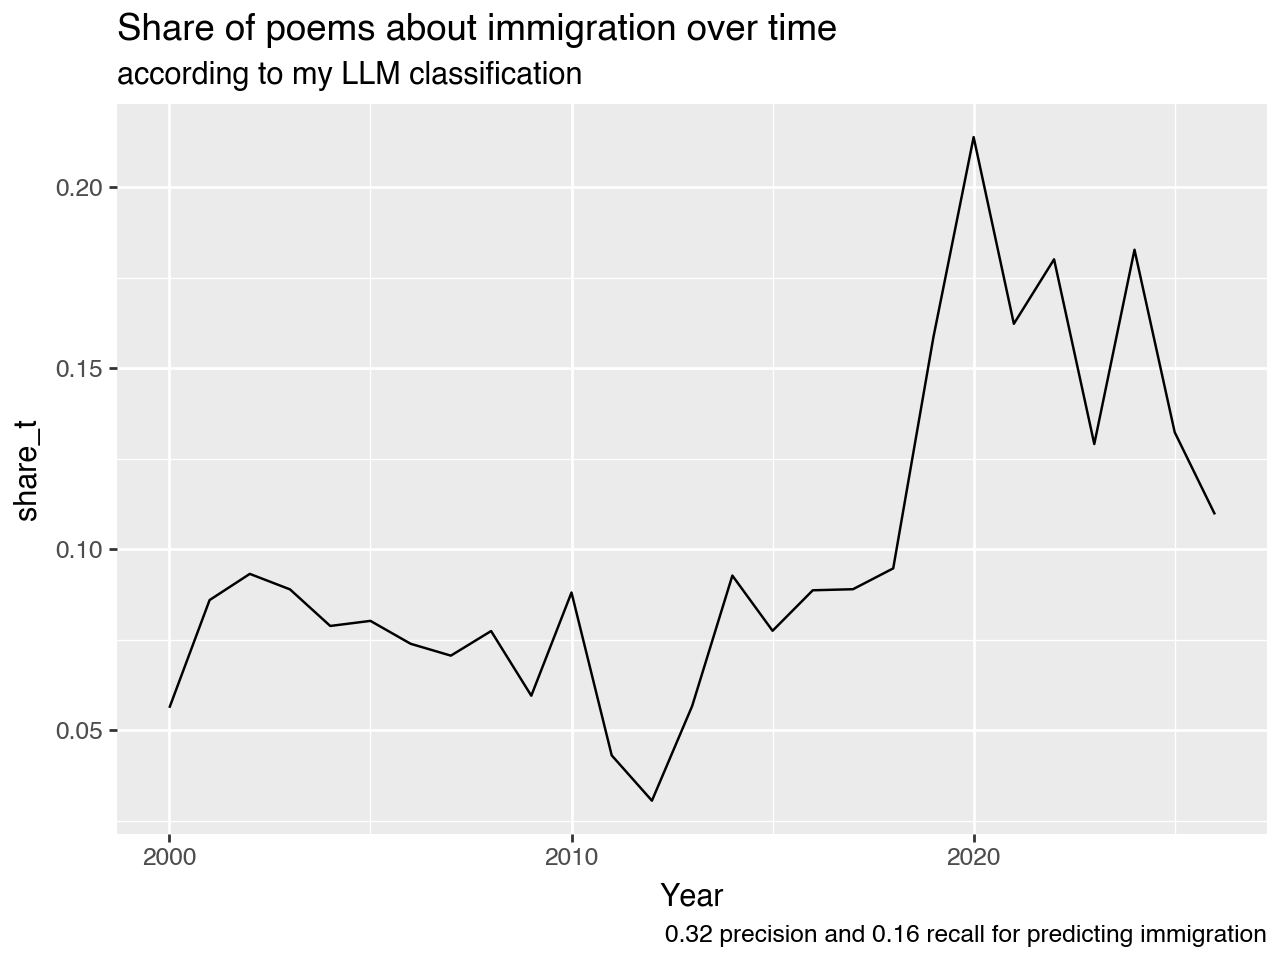

In [32]:
plot = (
    ggplot(df_new) + 
    aes(x='Year', y='share_t') +
    geom_line() +
    labs(title="Share of poems about immigration over time",
         subtitle="according to my LLM classification",
         caption="0.32 precision and 0.16 recall for predicting immigration")
)

plot